# Elo Ranking Tutorial

This notebook provides an introduction to the Elo rating system, demonstrates the theoretical relationship between rating differences and win probabilities, and shows how to perform a quick simulation in Python.

## 1. What is the Elo Rating System?

The **Elo rating system** is a method for calculating the relative skill levels of players in zero-sum games (like chess, or any head-to-head match). Each player has a numeric rating. After every match, the two players' ratings are updated based on:
1. The outcome of the match.
2. Their expected score (which depends on both players' current ratings).

### 1.1 Elo Update Formula

The Elo rating update for a player \( A \) after a match is:

$R_{\text{A,new}} = R_A + K \times (S_A - E_A)$

where:

- $R_A$: current rating of player \( A \)
- $R_{\text{A,new}}$: new rating of player \( A \)
- $K$: a constant (often in the range 16–32 in many applications)
- $S_A$: the actual score of player \( A \) (1 = win, 0.5 = draw, 0 = loss)
- $E_A$: the expected score of player \( A \), given by:

$$
E_A = \frac{1}{1 + 10^{\frac{(R_B - R_A)}{400}}}.
$$

## 2. Theoretical Rating Differences

### 2.1 Expected Score and Rating Difference

If a player's *expected score* against an opponent is $p$, you can solve for the rating difference:

$$
p = \frac{1}{1 + 10^{\frac{(R_B - R_A)}{400}}}
\quad \Longleftrightarrow \quad
1 + 10^{\frac{(R_B - R_A)}{400}} = \frac{1}{p}.
$$

Taking base-10 logarithms:

$$
10^{\frac{(R_B - R_A)}{400}} = \frac{1}{p} - 1
\quad \Longrightarrow \quad
\frac{(R_B - R_A)}{400} = \log_{10}\Bigl(\frac{1}{p} - 1\Bigr).
$$

Hence,

$$
R_A - R_B = -400 \cdot \log_{10}\Bigl(\frac{1}{p} - 1\Bigr).
$$

### 2.2 Example: 90% Win Rate

If Alice wins 90% of the time against Bob, we set $p = 0.9$:

$$
p = 0.9, \quad
\frac{1}{p} = 1.111\ldots, \quad
\frac{1}{p} - 1 = 0.111\ldots
$$

$$
\log_{10}(0.111\ldots) \approx -0.9542
\quad \Longrightarrow \quad
(R_A - R_B) \approx 400 \times 0.9542 \approx 382.
$$

So if one player truly has a 90% win chance over another, we expect their long-term Elo ratings to differ by roughly **380 points**.

## 3. Simple Elo Calculation Example

Below is a simple function in Python to compute expected score and update ratings for two players \( A \) and \( B \). Let's do one match where Alice beats Bob.

In [25]:
def expected_score(rating_a, rating_b):
    """
    Computes the expected score of player A vs. player B.
    """
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def update_elo(rating_a, rating_b, score_a, k_factor=32):
    """
    Given:
      - rating_a, rating_b: the current ratings for players A and B,
      - score_a: actual score of player A (1=win, 0.5=draw, 0=loss),
      - k_factor (K value in Elo),
    returns:
      new_rating_a, new_rating_b
    """
    exp_a = expected_score(rating_a, rating_b)
    exp_b = expected_score(rating_b, rating_a)
    
    # For a two-player match, B's score is (1 - score_a).
    score_b = 1 - score_a

    new_a = rating_a + k_factor * (score_a - exp_a)
    new_b = rating_b + k_factor * (score_b - exp_b)

    return new_a, new_b

# Example usage
R_alice = 1200
R_bob   = 1200

print(f"Before match: Alice={R_alice}, Bob={R_bob}")

# Suppose Alice wins
R_alice, R_bob = update_elo(R_alice, R_bob, score_a=1.0, k_factor=32)

print(f"After Alice beats Bob: Alice={R_alice:.2f}, Bob={R_bob:.2f}")

Before match: Alice=1200, Bob=1200
After Alice beats Bob: Alice=1216.00, Bob=1184.00


## 4. Simulation to See Long-Term Convergence

In the following simulation, let's assume:
- Alice has a *true* 90% chance to win each match (no draws).
- Bob wins 10% of the time.
- We update ratings after each match.
- We track how the rating difference evolves over many matches.

In [26]:
import random

def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def update_elo(rating_a, rating_b, score_a, k_factor=32):
    exp_a = expected_score(rating_a, rating_b)
    exp_b = expected_score(rating_b, rating_a)
    score_b = 1 - score_a
    new_a = rating_a + k_factor * (score_a - exp_a)
    new_b = rating_b + k_factor * (score_b - exp_b)
    return new_a, new_b

# Initial ratings
R_alice = 1200
R_bob   = 1200

K = 32
num_matches = 5000

diffs = []

for i in range(num_matches):
    # Simulate outcome: Alice 90% chance to win, Bob 10%.
    if random.random() < 0.9:
        # Alice wins
        R_alice, R_bob = update_elo(R_alice, R_bob, score_a=1, k_factor=K)
    else:
        # Bob wins
        R_alice, R_bob = update_elo(R_alice, R_bob, score_a=0, k_factor=K)
    
    # Track difference
    diffs.append(R_alice - R_bob)

print(f"After {num_matches} matches:")
print(f"Alice = {R_alice:.2f}, Bob = {R_bob:.2f}, Difference = {R_alice - R_bob:.2f}")

After 5000 matches:
Alice = 1417.18, Bob = 982.82, Difference = 434.35


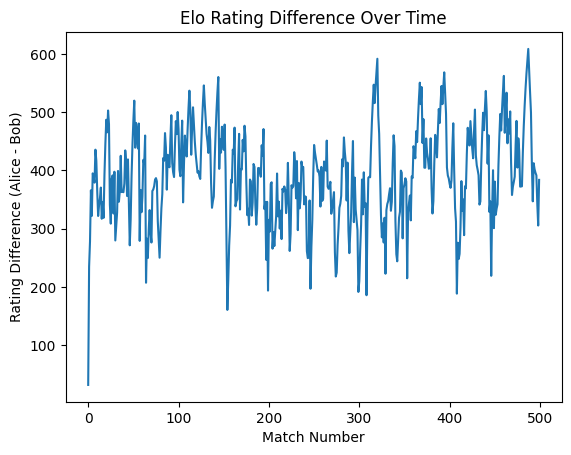

In [27]:
import matplotlib.pyplot as plt

plt.plot(diffs[::10])  # Plot every 10th point for clarity
plt.xlabel('Match Number')
plt.ylabel('Rating Difference (Alice - Bob)')
plt.title('Elo Rating Difference Over Time')
plt.show()

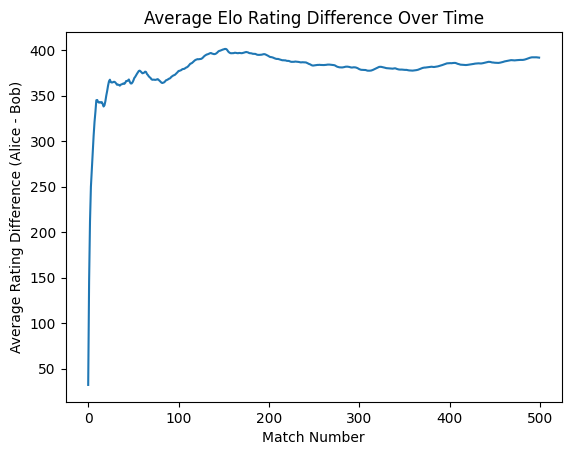

In [28]:
import numpy as np

# Calculate the running average of the rating differences
running_avg_diffs = [np.mean(diffs[:i+1]) for i in range(len(diffs))]

plt.plot(running_avg_diffs[::10])  # Plot every 10th point for clarity
plt.xlabel('Match Number')
plt.ylabel('Average Rating Difference (Alice - Bob)')
plt.title('Average Elo Rating Difference Over Time')
plt.show()

### Observations
- As the simulation runs, the difference `R_alice - R_bob` will grow toward around **380** points (though it will fluctuate due to random outcomes).
- The higher the number of matches, the closer it converges to that ballpark.

## 5. Key Takeaways

1. **Elo Formula**: Elo is updated after *each* match based on *expected vs. actual* results.
2. **Rating Differences**: A 400-point gap implies that the higher-rated player is about **90% favored**.
3. **K-Factor**: Higher K-factors produce faster rating changes but can be more volatile.
4. **Convergence**: Over many matches, ratings tend to “settle” around the skill-based difference implied by real win/loss rates.